# AI Gatekeeper Evaluation: Optimized Random Forest Classifier

Notebook ini fokus pada **evaluasi performa AI Gatekeeper** dengan parameter yang dioptimalkan untuk mengurangi overfitting dan meningkatkan generalisasi.

## 🎯 Tujuan:
- Melatih dan mengevaluasi **Random Forest Classifier** dengan hyperparameter konservatif
- Menganalisis **performa klasifikasi** (Accuracy, Precision, Recall, F1)
- Membandingkan **Actual vs Predicted** regime

## 📊 Configuration:
- **n_estimators**: 200
- **max_depth**: 5 (Restricted)
- **min_samples_split**: 20
- **min_samples_leaf**: 10

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 1. Data Loading & Preprocessing

In [2]:
# Load Data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
print(f"📊 Loaded {len(data)} rows of data")


📊 Loaded 990 rows of data


## 2. Feature Engineering

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Binary labeling: 0 = Bearish, 1 = Bullish
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

print("Feature shape:", features.shape)

Feature shape: (927, 4)


## 3. Train/Test Split

In [4]:
# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_test = features.loc[test_mask, 'Target']

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 562 samples
Testing set: 365 samples


## 4. Optimized Model Training

In [5]:
# Train Optimized Random Forest
print("🔄 Training Optimized Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          # Batasi depth lebih ketat
    min_samples_split=20, # Naikkan dari 10
    min_samples_leaf=10,  # Tambahkan leaf minimum
    max_features='sqrt',  # Batasi features per split
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Model trained successfully!")

🔄 Training Optimized Random Forest Classifier...
✅ Model trained successfully!


## 5. Performance Metrics

In [6]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{dataset_name} Performance")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Training metrics
train_metrics = calculate_metrics(y_train, y_train_pred, "TRAINING SET")

# Testing metrics
test_metrics = calculate_metrics(y_test, y_test_pred, "TESTING SET")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


TRAINING SET Performance
Accuracy:  0.7011 (70.11%)
Precision: 0.6782
Recall:    0.8782
F1-Score:  0.7654

TESTING SET Performance
Accuracy:  0.4904 (49.04%)
Precision: 0.5201
Recall:    0.7828
F1-Score:  0.6250

ROC-AUC Score: 0.4686


In [7]:
print("\n=== Detailed Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=['Bearish', 'Bullish']))


=== Detailed Classification Report (Test Set) ===
              precision    recall  f1-score   support

     Bearish       0.36      0.14      0.21       167
     Bullish       0.52      0.78      0.62       198

    accuracy                           0.49       365
   macro avg       0.44      0.46      0.42       365
weighted avg       0.45      0.49      0.43       365



## 6. Visualization

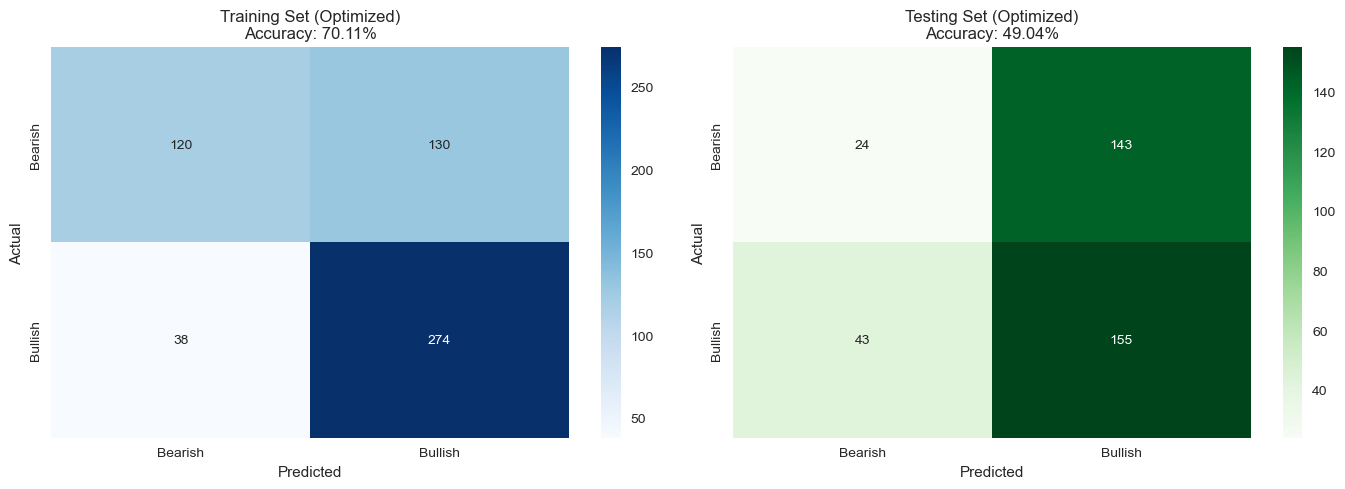

In [8]:
# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0])
axes[0].set_title(f'Training Set (Optimized)\nAccuracy: {train_metrics["Accuracy"]:.2%}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Testing
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1])
axes[1].set_title(f'Testing Set (Optimized)\nAccuracy: {test_metrics["Accuracy"]:.2%}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('optimized_confusion_matrix.png')
plt.show()

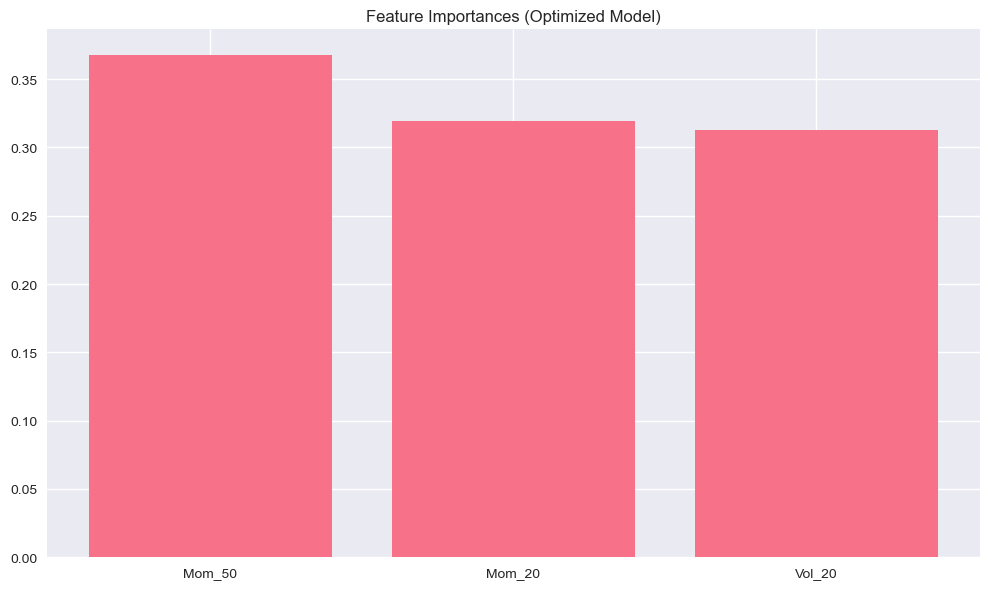

In [9]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Optimized Model)')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices])
plt.tight_layout()
plt.savefig('optimized_feature_importance.png')
plt.show()